## Atividade 1

Number of samples: 239616
Signal duration: 9.9840 s
Sample rate: 24000 Hz
Input normalization: True


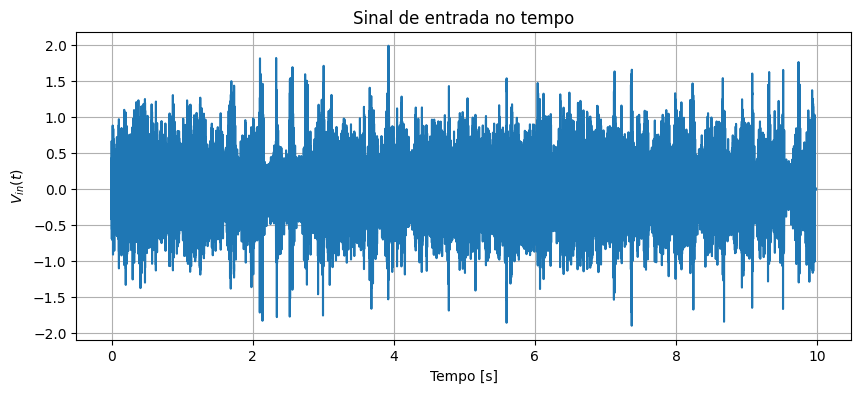

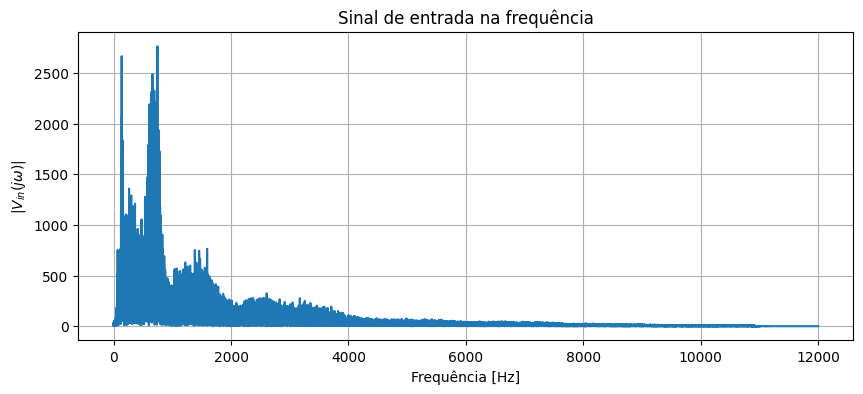

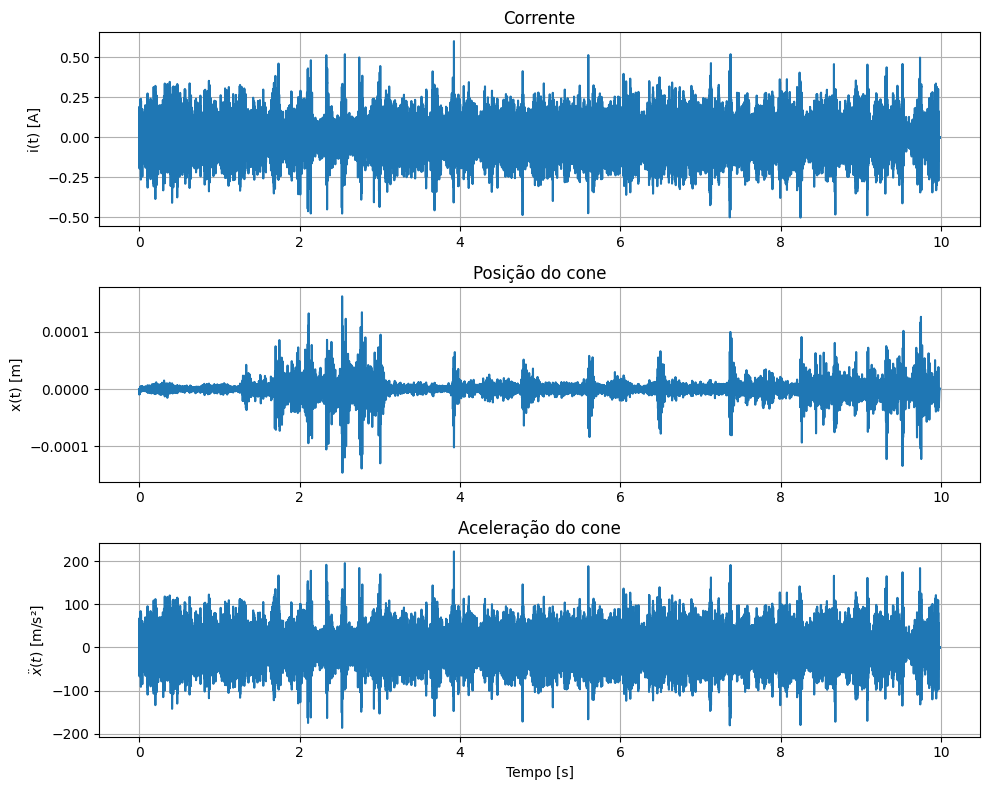

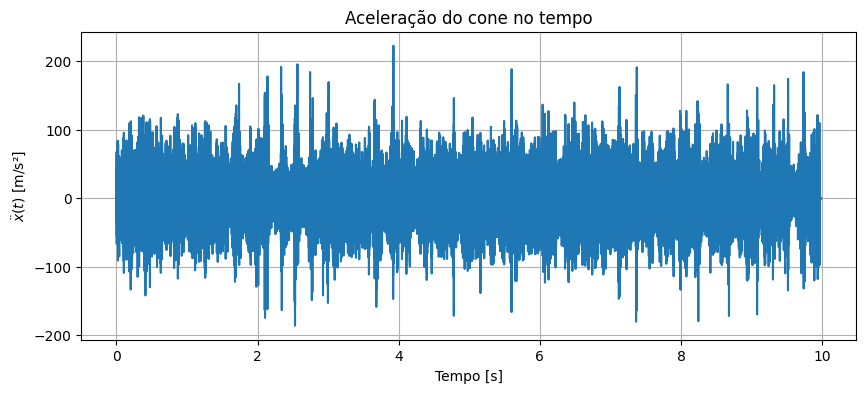

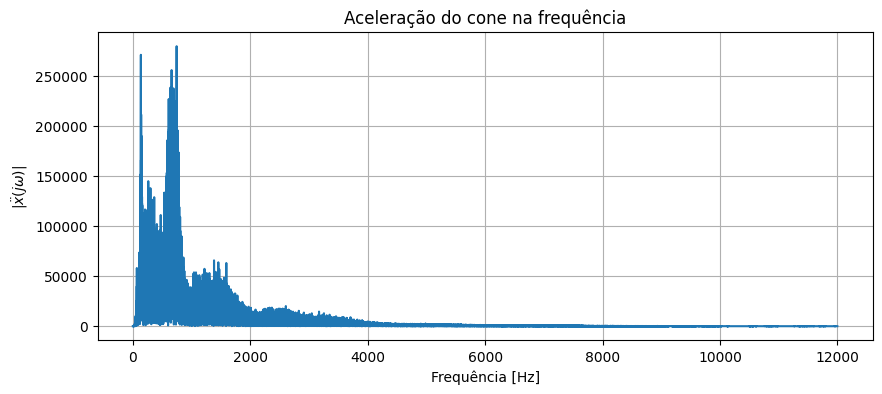

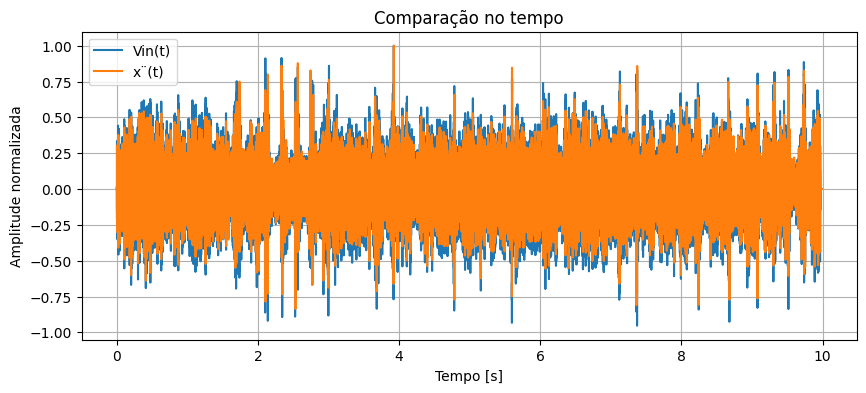

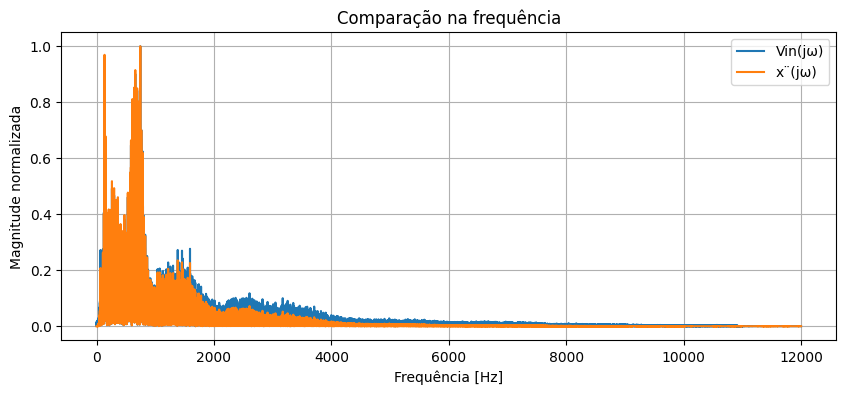

Arquivo salvo: TC02-out1.wav


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# =========================================================
# Configuração
# =========================================================
USE_INPUT_NORMALIZATION = True   # True = força |Vin| < 2.0 V
INPUT_VOLTAGE_LIMIT = 1.99       # valor de pico usado se normalizar

# =========================================================
# Leitura do arquivo
# =========================================================
sample_rate, data = wavfile.read('TC02-in.wav')
data = data.astype(float)

# Se estiver estéreo, usa apenas o canal 0
if data.ndim > 1:
    Vin = data[:, 0]
else:
    Vin = data

# Normalização opcional da entrada
if USE_INPUT_NORMALIZATION:
    Vin_max = np.max(np.abs(Vin))
    if Vin_max > 0:
        Vin = INPUT_VOLTAGE_LIMIT * Vin / Vin_max

# Vetor de tempo
num_samples = len(Vin)
duration = num_samples / sample_rate
time = np.arange(num_samples) / sample_rate

print(f"Number of samples: {num_samples}")
print(f"Signal duration: {duration:.4f} s")
print(f"Sample rate: {sample_rate} Hz")
print(f"Input normalization: {USE_INPUT_NORMALIZATION}")

# =========================================================
# Parâmetros do modelo linear
# =========================================================
m = 14.35e-3
b = 0.786
k = 1852
Bl = 4.95
L = 266e-6
R = 3.3

# =========================================================
# Matrizes de espaço de estados
# =========================================================
# Matriz A:
# descreve a dinâmica interna do sistema, ou seja,
# como as variáveis de estado [i, x, v] influenciam suas próprias derivadas [i_dot, x_dot, v_dot]
A = np.array([[-R/L,   0,   -Bl/L],   # i_dot depende de i e de v
              [0,      0,    1   ],   # x_dot = v
              [Bl/m, -k/m, -b/m  ]])  # v_dot depende de i, x e v

# Matriz B:
# define como a entrada u = Vin(t) entra no sistema
# aqui a tensão de entrada afeta diretamente apenas a equação da corrente
B = np.array([1/L, 0, 0])

# Matriz C:
# define qual variável do vetor de estado será escolhida como saída y(t)
# [0, 0, 1] significa que a saída escolhida é v, a velocidade do cone
C = np.array([0, 0, 1])

# Matriz identidade 3x3:
# normalmente usada em expressões no domínio da frequência,
# como em (jωI - A)^(-1)
I = np.eye(3)

# =========================================================
# Interpolação da entrada
# =========================================================
vin_interp = interp1d(time, Vin, bounds_error=False, fill_value=(Vin[0], Vin[-1]))

# =========================================================
# Modelo em espaço de estados
# =========================================================
def f(t, z):
    return A @ z + B * vin_interp(t)

# =========================================================
# Simulação
# =========================================================
sol = solve_ivp(f, [0, duration], [0, 0, 0], t_eval=time)

i = sol.y[0, :]
x = sol.y[1, :]
v = sol.y[2, :]
xdd = Bl/m * i - k/m * x - b/m * v

# =========================================================
# FFT
# =========================================================
N = len(Vin)
freq = np.fft.fftfreq(N, d=1/sample_rate)
idx = freq >= 0

Vin_fft = np.fft.fft(Vin)
xdd_fft = np.fft.fft(xdd)

# =========================================================
# Vin(t)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(time, Vin)
plt.xlabel('Tempo [s]')
plt.ylabel('$V_{in}(t)$')
plt.title('Sinal de entrada no tempo')
plt.grid(True)
plt.show()

# =========================================================
# Vin(jw)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(Vin_fft[idx]))
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|V_{in}(j\omega)|$')
plt.title('Sinal de entrada na frequência')
plt.grid(True)
plt.show()

# =========================================================
# i(t), x(t), x¨(t)
# =========================================================
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(sol.t, i)
plt.ylabel('i(t) [A]')
plt.title('Corrente')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(sol.t, x)
plt.ylabel('x(t) [m]')
plt.title('Posição do cone')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(sol.t, xdd)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone')
plt.grid(True)

plt.tight_layout()
plt.show()

# =========================================================
# x¨(t)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(sol.t, xdd)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone no tempo')
plt.grid(True)
plt.show()

# =========================================================
# x¨(jw)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(xdd_fft[idx]))
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|\ddot{x}(j\omega)|$')
plt.title('Aceleração do cone na frequência')
plt.grid(True)
plt.show()

# =========================================================
# Comparação no tempo
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(time, Vin / np.max(np.abs(Vin)), label='Vin(t)')
plt.plot(time, xdd / np.max(np.abs(xdd)), label='x¨(t)')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude normalizada')
plt.title('Comparação no tempo')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Comparação na frequência
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(Vin_fft[idx]) / np.max(np.abs(Vin_fft[idx])), label='Vin(jω)')
plt.plot(freq[idx], np.abs(xdd_fft[idx]) / np.max(np.abs(xdd_fft[idx])), label='x¨(jω)')
plt.xlabel('Frequência [Hz]')
plt.ylabel('Magnitude normalizada')
plt.title('Comparação na frequência')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Salvar saída
# =========================================================
out = xdd.copy()
out_max = np.max(np.abs(out))
if out_max > 0:
    out = out / out_max

wavfile.write('TC02-out1.wav', sample_rate, out.astype(np.float32))
print('Arquivo salvo: TC02-out1.wav')

## Atividade 2

x_max = 1.617548e-04 m
x1    = 1.213161e-04 m
x2    = 2.426321e-04 m


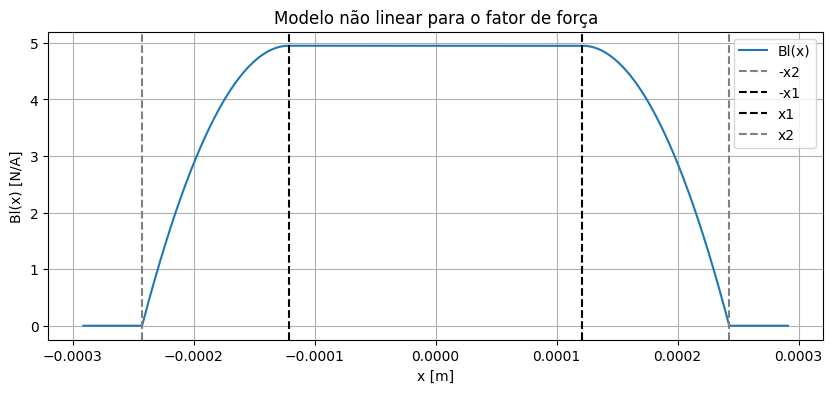

In [2]:
# =========================================================
# ATIVIDADE 02 - Criando um modelo não linear para o alto-falante
# =========================================================

# excursão máxima do cone no modelo linear
x_max = np.max(np.abs(x))

# limites pedidos no enunciado
x1 = 0.75 * x_max
x2 = 1.50 * x_max

print(f"x_max = {x_max:.6e} m")
print(f"x1    = {x1:.6e} m")
print(f"x2    = {x2:.6e} m")

# Função Bl(x) não linear:
# - para |x| <= x1: Bl(x) = Bl
# - para |x| >= x2: Bl(x) = 0
# - para x1 < |x| < x2: decaimento polinomial de ordem 2
def Bl_nonlinear(xpos):
    absx = np.abs(xpos)

    if absx <= x1:
        return Bl
    elif absx >= x2:
        return 0.0
    else:
        s = (absx - x1) / (x2 - x1)
        return Bl * (1 - s**2)

# Gera pontos para visualizar a curva Bl(x)
x_plot = np.linspace(-1.2 * x2, 1.2 * x2, 1000)
Bl_plot = np.array([Bl_nonlinear(xpos) for xpos in x_plot])

# Gráfico do fator de força não linear
plt.figure(figsize=(10, 4))
plt.plot(x_plot, Bl_plot, label='Bl(x)')
plt.axvline(-x2, linestyle='--', color='gray', label='-x2')
plt.axvline(-x1, linestyle='--', color='black', label='-x1')
plt.axvline( x1, linestyle='--', color='black', label='x1')
plt.axvline( x2, linestyle='--', color='gray', label='x2')
plt.xlabel('x [m]')
plt.ylabel('Bl(x) [N/A]')
plt.title('Modelo não linear para o fator de força')
plt.grid(True)
plt.legend()
plt.show()

## Atividade 3

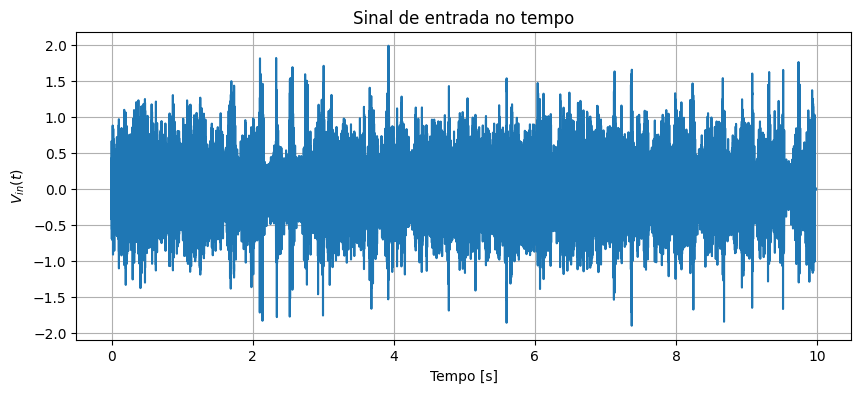

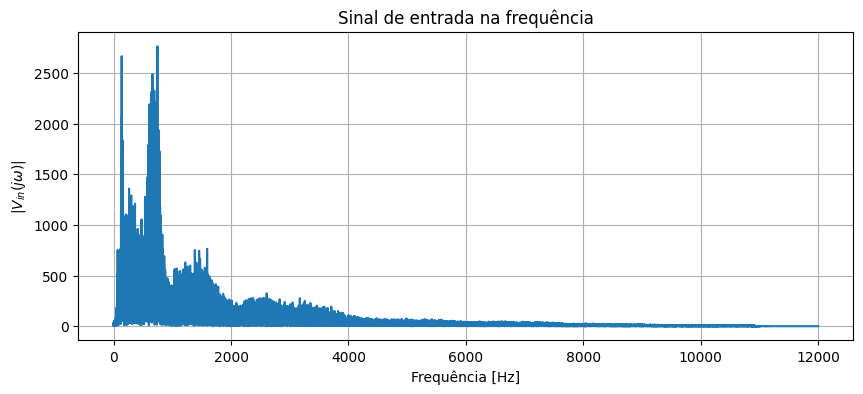

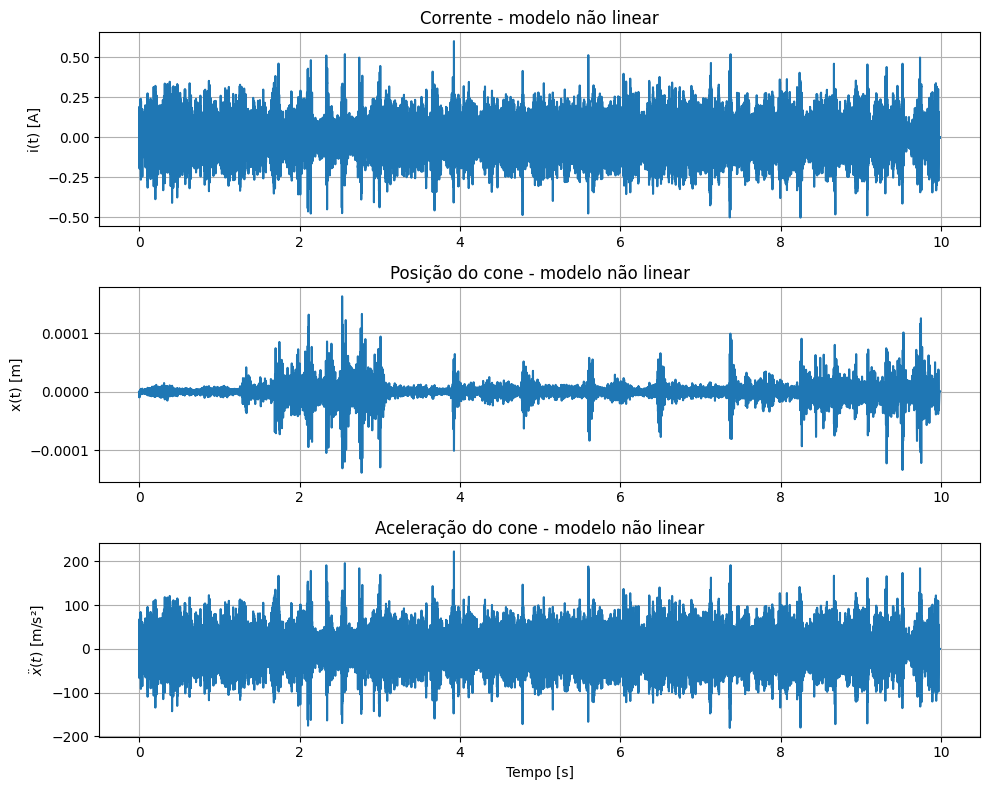

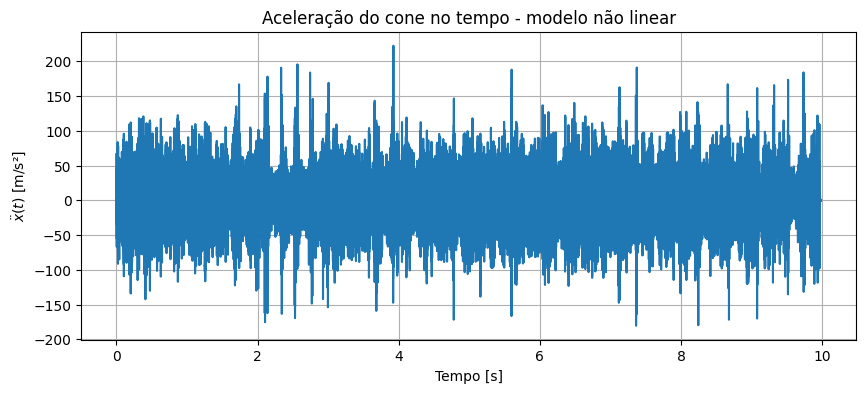

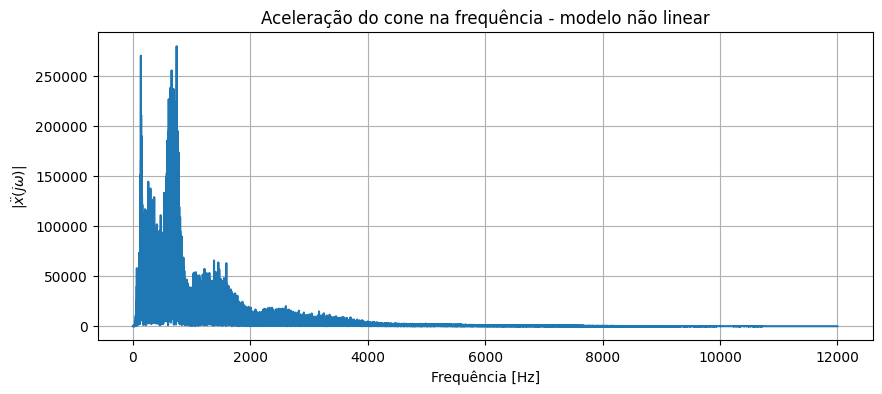

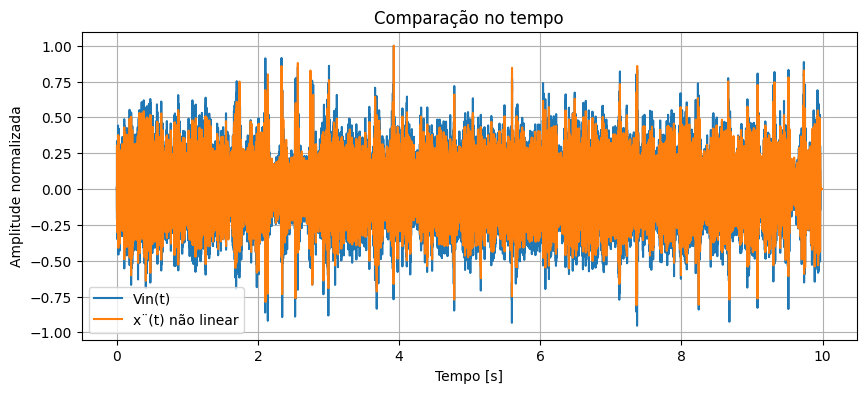

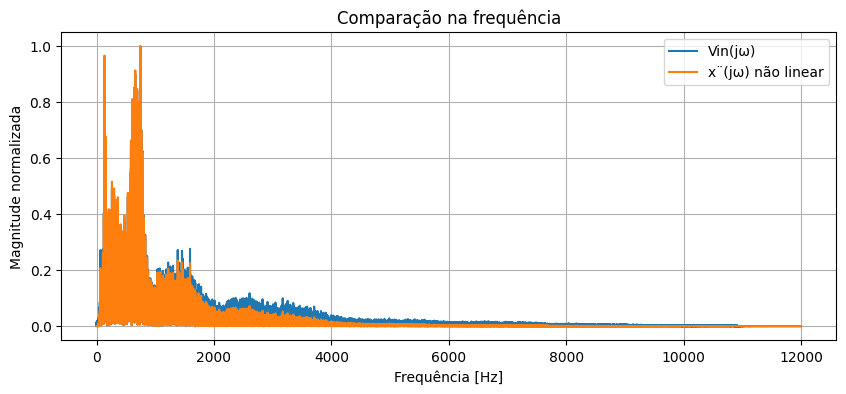

Arquivo salvo: TC02-out2.wav


In [3]:
# =========================================================
# ATIVIDADE 03 - Implementando e avaliando o modelo não linear
# =========================================================

# Modelo não linear em espaço de estados
def f_nl(t, z):
    i = z[0]
    xpos = z[1]
    v = z[2]

    # Bl depende agora da posição do cone
    Blx = Bl_nonlinear(xpos)

    # entrada interpolada
    u = vin_interp(t)

    # equações governantes do modelo não linear
    di_dt = (-R * i - Blx * v + u) / L
    dx_dt = v
    dv_dt = (Blx * i - k * xpos - b * v) / m

    return np.array([di_dt, dx_dt, dv_dt])

# Simulação do modelo não linear
sol_nl = solve_ivp(f_nl, [0, duration], [0, 0, 0], t_eval=time)

# Variáveis de estado
i_nl = sol_nl.y[0, :]
x_nl = sol_nl.y[1, :]
v_nl = sol_nl.y[2, :]

# Bl(x) avaliado ao longo da trajetória
Bl_nl_vals = np.array([Bl_nonlinear(xpos) for xpos in x_nl])

# Aceleração do cone no modelo não linear
xdd_nl = (Bl_nl_vals / m) * i_nl - (k / m) * x_nl - (b / m) * v_nl

# =========================================================
# FFT
# =========================================================
N = len(Vin)
freq = np.fft.fftfreq(N, d=1/sample_rate)
idx = freq >= 0

Vin_fft = np.fft.fft(Vin)
xdd_nl_fft = np.fft.fft(xdd_nl)

# =========================================================
# Vin(t)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(time, Vin)
plt.xlabel('Tempo [s]')
plt.ylabel('$V_{in}(t)$')
plt.title('Sinal de entrada no tempo')
plt.grid(True)
plt.show()

# =========================================================
# Vin(jw)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(Vin_fft[idx]))
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|V_{in}(j\omega)|$')
plt.title('Sinal de entrada na frequência')
plt.grid(True)
plt.show()

# =========================================================
# i(t), x(t), x¨(t)
# =========================================================
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(sol_nl.t, i_nl)
plt.ylabel('i(t) [A]')
plt.title('Corrente - modelo não linear')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(sol_nl.t, x_nl)
plt.ylabel('x(t) [m]')
plt.title('Posição do cone - modelo não linear')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(sol_nl.t, xdd_nl)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone - modelo não linear')
plt.grid(True)

plt.tight_layout()
plt.show()

# =========================================================
# x¨(t)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(sol_nl.t, xdd_nl)
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone no tempo - modelo não linear')
plt.grid(True)
plt.show()

# =========================================================
# x¨(jw)
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(freq[idx], np.abs(xdd_nl_fft[idx]))
plt.xlabel('Frequência [Hz]')
plt.ylabel(r'$|\ddot{x}(j\omega)|$')
plt.title('Aceleração do cone na frequência - modelo não linear')
plt.grid(True)
plt.show()

# =========================================================
# Comparação com Vin no tempo
# =========================================================
Vin_norm = Vin / np.max(np.abs(Vin))
xdd_nl_norm = xdd_nl / np.max(np.abs(xdd_nl))

plt.figure(figsize=(10, 4))
plt.plot(time, Vin_norm, label='Vin(t)')
plt.plot(time, xdd_nl_norm, label='x¨(t) não linear')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude normalizada')
plt.title('Comparação no tempo')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Comparação com Vin na frequência
# =========================================================
Vin_fft_norm = np.abs(Vin_fft[idx]) / np.max(np.abs(Vin_fft[idx]))
xdd_nl_fft_norm = np.abs(xdd_nl_fft[idx]) / np.max(np.abs(xdd_nl_fft[idx]))

plt.figure(figsize=(10, 4))
plt.plot(freq[idx], Vin_fft_norm, label='Vin(jω)')
plt.plot(freq[idx], xdd_nl_fft_norm, label='x¨(jω) não linear')
plt.xlabel('Frequência [Hz]')
plt.ylabel('Magnitude normalizada')
plt.title('Comparação na frequência')
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# Salvar saída
# =========================================================
out2 = xdd_nl.copy()
out2_max = np.max(np.abs(out2))
if out2_max > 0:
    out2 = out2 / out2_max

wavfile.write('TC02-out2.wav', sample_rate, out2.astype(np.float32))
print('Arquivo salvo: TC02-out2.wav')

## Atividade 4

Frequência escolhida: 150.0 Hz
Número de períodos: 40
Duração do sinal: 0.266667 s
Amplitude: 2.0 V  (4.0 Vpp)


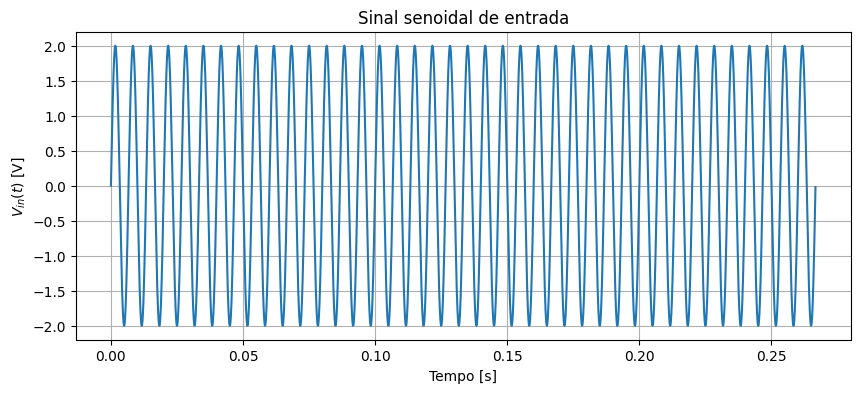

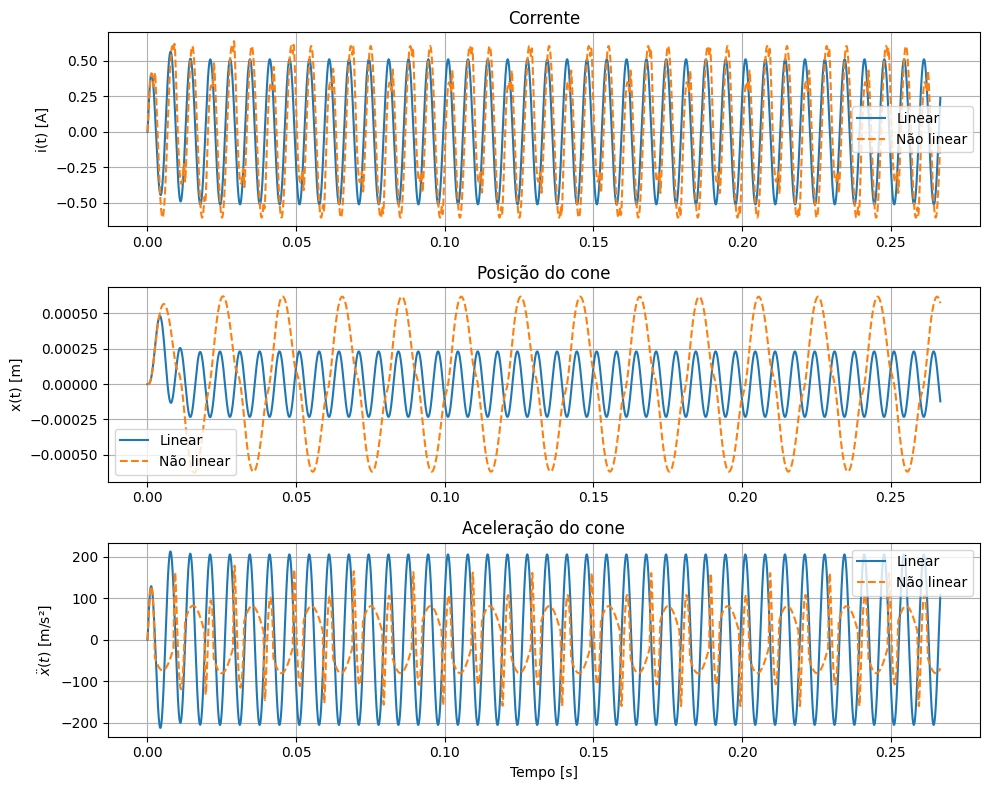

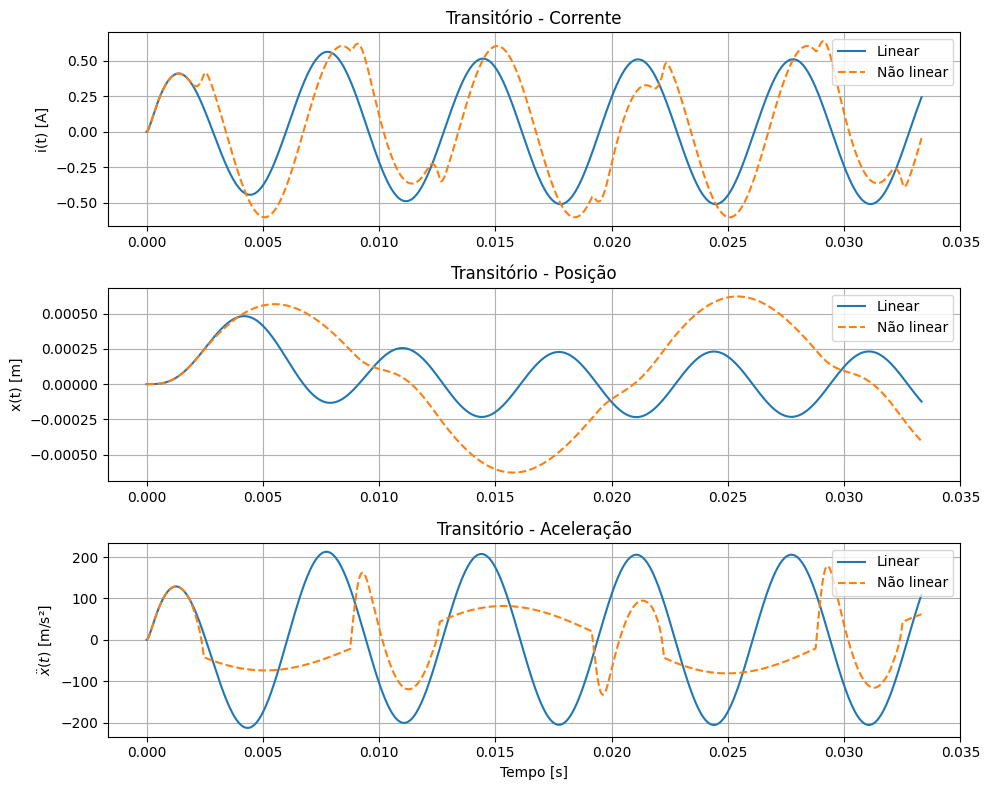

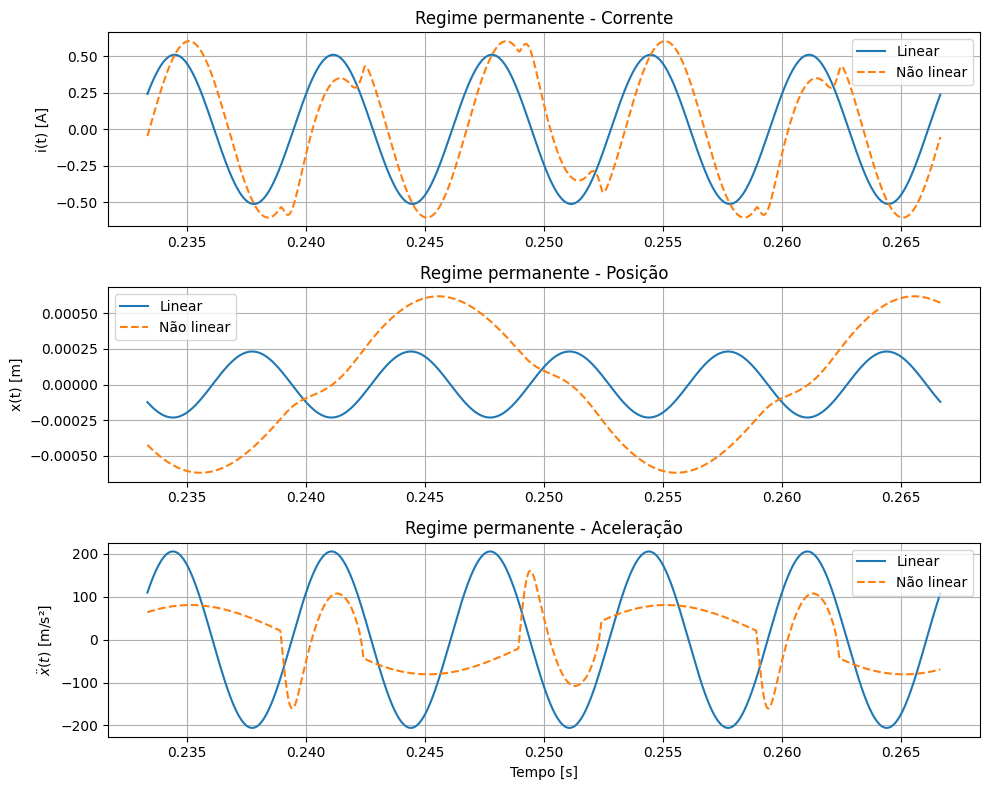

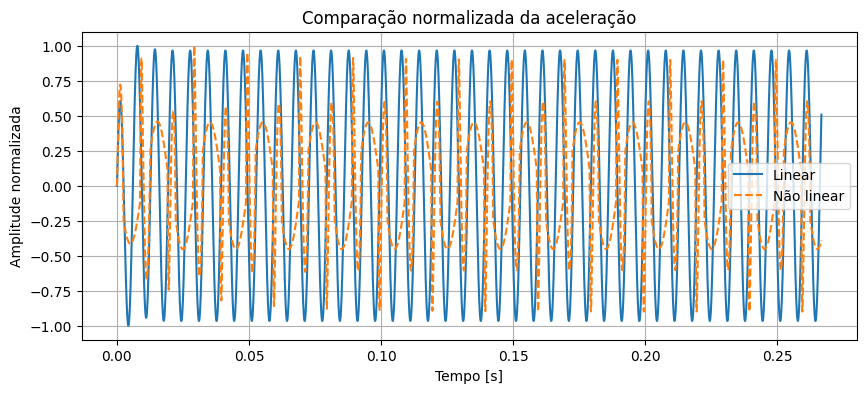

In [4]:
# =========================================================
# ATIVIDADE 04 - Resposta a um sinal senoidal
# =========================================================
# Esta célula assume que já existem:
# m, b, k, Bl, L, R
# e a função Bl_nonlinear(xpos) definida na Atividade 02

# -----------------------------
# Sinal senoidal de entrada
# -----------------------------
f0 = 150.0          # Hz -> dentro da faixa da voz humana
periods = 40        # >= 20 períodos
Ain = 2.0           # amplitude de 2 V -> 4 Vpp
duration_sin = periods / f0

fs_sim = 96000      # taxa de amostragem "virtual" para a simulação
t_sin = np.linspace(0, duration_sin, int(fs_sim * duration_sin), endpoint=False)

Vin_sin = Ain * np.sin(2 * np.pi * f0 * t_sin)

print(f"Frequência escolhida: {f0} Hz")
print(f"Número de períodos: {periods}")
print(f"Duração do sinal: {duration_sin:.6f} s")
print(f"Amplitude: {Ain} V  ({2*Ain} Vpp)")

# -----------------------------
# Entrada interpolada
# -----------------------------
vin_sin_interp = interp1d(
    t_sin,
    Vin_sin,
    bounds_error=False,
    fill_value=(Vin_sin[0], Vin_sin[-1])
)

# -----------------------------
# Modelo linear
# -----------------------------
A_lin = np.array([[-R/L,   0,   -Bl/L],
                  [0,      0,    1   ],
                  [Bl/m, -k/m, -b/m  ]])

B_lin = np.array([1/L, 0, 0])

def f_linear_sin(t, z):
    return A_lin @ z + B_lin * vin_sin_interp(t)

sol_lin_sin = solve_ivp(
    f_linear_sin,
    [0, duration_sin],
    [0, 0, 0],
    t_eval=t_sin,
    rtol=1e-7,
    atol=1e-9
)

i_lin_sin = sol_lin_sin.y[0, :]
x_lin_sin = sol_lin_sin.y[1, :]
v_lin_sin = sol_lin_sin.y[2, :]
xdd_lin_sin = (Bl / m) * i_lin_sin - (k / m) * x_lin_sin - (b / m) * v_lin_sin

# -----------------------------
# Modelo não linear
# -----------------------------
def f_nl_sin(t, z):
    i = z[0]
    xpos = z[1]
    v = z[2]

    Blx = Bl_nonlinear(xpos)
    u = vin_sin_interp(t)

    di_dt = (-R * i - Blx * v + u) / L
    dx_dt = v
    dv_dt = (Blx * i - k * xpos - b * v) / m

    return np.array([di_dt, dx_dt, dv_dt])

sol_nl_sin = solve_ivp(
    f_nl_sin,
    [0, duration_sin],
    [0, 0, 0],
    t_eval=t_sin,
    rtol=1e-7,
    atol=1e-9
)

i_nl_sin = sol_nl_sin.y[0, :]
x_nl_sin = sol_nl_sin.y[1, :]
v_nl_sin = sol_nl_sin.y[2, :]

Bl_nl_sin_vals = np.array([Bl_nonlinear(xpos) for xpos in x_nl_sin])
xdd_nl_sin = (Bl_nl_sin_vals / m) * i_nl_sin - (k / m) * x_nl_sin - (b / m) * v_nl_sin

# -----------------------------
# Gráfico do sinal de entrada
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_sin, Vin_sin)
plt.xlabel('Tempo [s]')
plt.ylabel('$V_{in}(t)$ [V]')
plt.title('Sinal senoidal de entrada')
plt.grid(True)
plt.show()

# -----------------------------
# Comparação completa: linear x não linear
# -----------------------------
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t_sin, i_lin_sin, label='Linear')
plt.plot(t_sin, i_nl_sin, '--', label='Não linear')
plt.ylabel('i(t) [A]')
plt.title('Corrente')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sin, x_lin_sin, label='Linear')
plt.plot(t_sin, x_nl_sin, '--', label='Não linear')
plt.ylabel('x(t) [m]')
plt.title('Posição do cone')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sin, xdd_lin_sin, label='Linear')
plt.plot(t_sin, xdd_nl_sin, '--', label='Não linear')
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Aceleração do cone')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Transitório: primeiros 5 períodos
# -----------------------------
t_trans_end = 5 / f0
idx_trans = t_sin <= t_trans_end

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t_sin[idx_trans], i_lin_sin[idx_trans], label='Linear')
plt.plot(t_sin[idx_trans], i_nl_sin[idx_trans], '--', label='Não linear')
plt.ylabel('i(t) [A]')
plt.title('Transitório - Corrente')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sin[idx_trans], x_lin_sin[idx_trans], label='Linear')
plt.plot(t_sin[idx_trans], x_nl_sin[idx_trans], '--', label='Não linear')
plt.ylabel('x(t) [m]')
plt.title('Transitório - Posição')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sin[idx_trans], xdd_lin_sin[idx_trans], label='Linear')
plt.plot(t_sin[idx_trans], xdd_nl_sin[idx_trans], '--', label='Não linear')
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Transitório - Aceleração')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Regime permanente: últimos 5 períodos
# -----------------------------
t_perm_start = duration_sin - 5 / f0
idx_perm = t_sin >= t_perm_start

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t_sin[idx_perm], i_lin_sin[idx_perm], label='Linear')
plt.plot(t_sin[idx_perm], i_nl_sin[idx_perm], '--', label='Não linear')
plt.ylabel('i(t) [A]')
plt.title('Regime permanente - Corrente')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sin[idx_perm], x_lin_sin[idx_perm], label='Linear')
plt.plot(t_sin[idx_perm], x_nl_sin[idx_perm], '--', label='Não linear')
plt.ylabel('x(t) [m]')
plt.title('Regime permanente - Posição')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sin[idx_perm], xdd_lin_sin[idx_perm], label='Linear')
plt.plot(t_sin[idx_perm], xdd_nl_sin[idx_perm], '--', label='Não linear')
plt.xlabel('Tempo [s]')
plt.ylabel(r'$\ddot{x}(t)$ [m/s²]')
plt.title('Regime permanente - Aceleração')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Comparação normalizada da aceleração
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_sin, xdd_lin_sin / np.max(np.abs(xdd_lin_sin)), label='Linear')
plt.plot(t_sin, xdd_nl_sin / np.max(np.abs(xdd_nl_sin)), '--', label='Não linear')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude normalizada')
plt.title('Comparação normalizada da aceleração')
plt.grid(True)
plt.legend()
plt.show()